In this task, we assume that both u and sigma are unknown and we find the ratio of u/sigma.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# Simulate the process
T = 10.0                       # Total simulation time.
tau_e = 0.06                    # Correlation decay parameter for the process.
tau_f = 0.005                   # Second correlation parameter.
dt = 0.05 * min(tau_e, tau_f)   # Time discretization step for simulation of the process.
sigma = 2.0                     # Standard deviation of the process.
u = 0.5                         # Threshold.
n = 100                         # Number of trials

print(f"psi of the real process : {u / sigma}")

psi of the real process : 0.25


In [3]:
# Simulate the process and record the crossing times.
upcrossing_times = []
downcrossing_times = []

for i in range(n):
    t, x = utils.simulate_gaussian_process_fft(
        process.r_OU_noise, T, dt,
        sigma=sigma, tau=tau_e, kappa=tau_f/tau_e
    )
    upcrossing_times.append(utils.upcrossing_times(x=x, t=t, threshold=u))
    downcrossing_times.append(utils.downcrossing_times(x=x, t=t, threshold=u))

# --------------------------------------------------------------------
# Compute observed upcrossings count per trial
observed_counts = torch.tensor([len(times) for times in upcrossing_times], dtype=torch.float32)
# print("Observed counts:", observed_counts.tolist())

In [4]:
# functions to find the mean and variance of the upcrossing counts.
model = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u, tau=tau_e, kappa=tau_f/tau_e, sigma=sigma)
mean_num_upcrossings = model.upcrossing_mean(T)
variance_num_upcrossings = model.upcrossing_variance(T)
variance_num_upcrossings_CLT = model.upcrossing_variance_CLT(T)

# print the mean and variance of the upcrossing counts.
print(f"Analytical mean number of upcrossings: {mean_num_upcrossings}")
print(f"Analytical variance of the number of upcrossings: {variance_num_upcrossings}")
print(f"Analytical variance (CLT) of the number of upcrossings: {variance_num_upcrossings_CLT}")

# print the numerical mean and variance of the upcrossing counts.
print(f"Numerical mean number of upcrossings: {observed_counts.mean()}")
print(f"Numerical variance of the number of upcrossings: {observed_counts.var()}")
print(f"Numerical variance (biased) of the number of upcrossings: {torch.var(observed_counts, correction=0)}")


# the values to fit to
# true_mean = observed_counts.mean()
# true_var = torch.var(observed_counts, correction=0) # biased estimate as given by the log likelihood

true_mean = mean_num_upcrossings
true_var = variance_num_upcrossings

Analytical mean number of upcrossings: 61.21070351357303
Analytical variance of the number of upcrossings: 91.3723068584051
Analytical variance (CLT) of the number of upcrossings: 91.56737149636558
Numerical mean number of upcrossings: 61.5099983215332
Numerical variance of the number of upcrossings: 93.06050872802734
Numerical variance (biased) of the number of upcrossings: 92.12989807128906


In [5]:
# Set up parameters for optimization.
# We optimize log parameters so that the exponentiated values remain positive.
# log_tau_e = torch.tensor(np.log(tau_e), dtype=torch.float64, requires_grad=True)
# log_tau_f = torch.tensor(np.log(tau_f), dtype=torch.float64, requires_grad=True)
# log_sigma = torch.tensor(np.log(sigma), dtype=torch.float64, requires_grad=True)


u_assumed = 1.0 # assume u=1.0, therefore, psi = 1 / sigma
log_tau_e = torch.tensor(np.log(0.1), dtype=torch.float64, requires_grad=True)
log_tau_f = torch.tensor(np.log(0.005), dtype=torch.float64, requires_grad=False)
log_sigma = torch.tensor(np.log(1.0), dtype=torch.float64, requires_grad=True)


# print the intial parameters
print("Initial parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item()}")
print(f"tau_f: {torch.exp(log_tau_f).item()}")
print(f"kappa: {torch.exp(log_tau_f).item() / torch.exp(log_tau_e).item()}")
print(f"psi: {u_assumed / torch.exp(log_sigma).item()}")

print("Analytical mean and variance with intial parameters:")
model_init = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u_assumed, tau=torch.exp(log_tau_e).item(), kappa=torch.exp(log_tau_f).item() / torch.exp(log_tau_e).item(), sigma=torch.exp(log_sigma).item())
mean_num_upcrossings_init = model_init.upcrossing_mean(T)
variance_num_upcrossings_init = model_init.upcrossing_variance(T)
print(f"Mean number of upcrossings : {mean_num_upcrossings_init}")
print(f"Variance of the number of upcrossings : {variance_num_upcrossings_init}")

print(f"epsilon_right = {1 - (T / torch.exp(log_tau_e).item()) / (1 + (T / torch.exp(log_tau_e).item()))}")


# Choose an optimizer
optimizer = torch.optim.Adam([log_tau_e, log_tau_f, log_sigma], lr=1e-2)


Initial parameters:
tau_e: 0.10000000000000002
tau_f: 0.005000000000000002
kappa: 0.05000000000000001
psi: 1.0
Analytical mean and variance with intial parameters:
Mean number of upcrossings : 0.0019599413225854334
Variance of the number of upcrossings : 0.0026813389122335675
epsilon_right = 0.00990099009900991


Epoch    0: Loss = 12094.9185, tau_e = 0.100000, tau_f = 0.005000, kappa = 0.050000, psi = 1.000000
Epoch  100: Loss = 31.4271, tau_e = 0.036419, tau_f = 0.005000, kappa = 0.137290, psi = 0.370430
Epoch  200: Loss = 11.9997, tau_e = 0.037828, tau_f = 0.005000, kappa = 0.132178, psi = 0.375202
Epoch  300: Loss = 11.4036, tau_e = 0.038217, tau_f = 0.005000, kappa = 0.130832, psi = 0.372313
Epoch  400: Loss = 10.7248, tau_e = 0.038671, tau_f = 0.005000, kappa = 0.129294, psi = 0.368876
Epoch  500: Loss = 9.9866, tau_e = 0.039187, tau_f = 0.005000, kappa = 0.127594, psi = 0.365046
Epoch  600: Loss = 9.2208, tau_e = 0.039754, tau_f = 0.005000, kappa = 0.125774, psi = 0.360910
Epoch  700: Loss = 8.4383, tau_e = 0.040366, tau_f = 0.005000, kappa = 0.123868, psi = 0.356541
Epoch  800: Loss = 7.6580, tau_e = 0.041014, tau_f = 0.005000, kappa = 0.121908, psi = 0.352004
Epoch  900: Loss = 6.9012, tau_e = 0.041694, tau_f = 0.005000, kappa = 0.119921, psi = 0.347357
Optimization complete!
Estimated

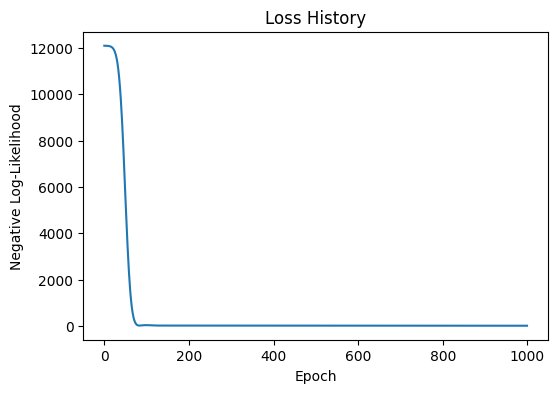

In [6]:

# For tracking the loss history
num_epochs = 1000
loss_history = []

# --------------------------------------------------------------------
# Optimization loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Convert log parameters to actual parameters ensuring positivity.
    tau_e_est = torch.exp(log_tau_e)
    tau_f_est = torch.exp(log_tau_f)
    sigma_est = torch.exp(log_sigma)
    kappa_est = tau_f_est / tau_e_est  # kappa is defined as tau_f/tau_e.
    
    # Create a model instance with the current estimates.
    model_est = formula.GaussianUpCrossingsDimless(
        r_func=process.r_OU_noise, u=u_assumed, tau=tau_e_est, kappa=kappa_est, sigma=sigma_est
    )
    
    # Compute the predicted mean and variance for the number of upcrossings over time T.
    mean_est = model_est.upcrossing_mean(T)
    # var_est = model_est.upcrossing_variance(T)
    var_est = model_est.upcrossing_variance_CLT(T)

    # print(f"Mean number of upcrossings: {mean_est}")
    # print(f"Variance of the number of upcrossings: {var_est}")
    
    # Define the negative log likelihood assuming a Gaussian likelihood for the counts.
    # For each trial, NLL = 0.5*log(2*pi*var) + 0.5*(observed - mean)^2 / var.
    # nll = 0.5 * torch.log(2 * torch.pi * var_est) + 0.5 * ((observed_counts - mean_est)**2) / var_est
    # # nll = (observed_counts - mean_est)**2 ## minimize the mean
    # loss = nll.mean()  # Sum over all trials.

    
    # loss = (mean_est - true_mean) ** 2 ## minimize the mean
    # loss = (var_est - true_var) ** 2 ## minimize the variance
    loss = (mean_est - true_mean) ** 2 + (var_est - true_var) ** 2 ## minimize both mean and variance

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}: Loss = {loss.item():.4f}, "
              f"tau_e = {tau_e_est.item():.6f}, tau_f = {tau_f_est.item():.6f}, kappa = {(tau_f_est.item() / tau_e_est.item()):.6f}, psi = {u_assumed / sigma_est.item():.6f}")

    
    # Backpropagate the loss.
    loss.backward()

    # print the gradient for each parameter
    # print(f"Gradient tau_e: {log_tau_e.grad}")
    # print(f"Gradient sigma : {log_sigma.grad}")

    optimizer.step()
    
    loss_history.append(loss.item())
    

print("Optimization complete!")
print("Estimated parameters:")
print(f"tau_e: {torch.exp(log_tau_e).item()}")
print(f"tau_f: {torch.exp(log_tau_f).item()}")
print(f"psi: {u_assumed / torch.exp(log_sigma).item()}")

# Optional: Plot loss history
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Loss History")
plt.show()

In [7]:
# print the simulation mean and variance with true paramters and learned paramteres
print("Simulation mean and variance with true parameters:")
print(f"Mean number of upcrossings: {torch.mean(observed_counts)}")
print(f"Variance of the number of upcrossings: {torch.var(observed_counts, correction=0)}")
print(f"Variance (biased) of the number of upcrossings: {torch.var(observed_counts, correction=0)} \n")

# print the analytical mean and variance with true paramters and learned paramteres
print("Analytical mean and variance with true parameters:")
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings} \n")


print("Analytical mean and variance with estimated parameters:")
model_est = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u_assumed, tau=tau_e_est, kappa=kappa_est, sigma=sigma_est)
mean_num_upcrossings_est = model_est.upcrossing_mean(T)
variance_num_upcrossings_est = model_est.upcrossing_variance(T)
print(f"Mean number of upcrossings (estimated): {mean_num_upcrossings_est}")
print(f"Variance of the number of upcrossings (estimated): {variance_num_upcrossings_est}")

Simulation mean and variance with true parameters:
Mean number of upcrossings: 61.5099983215332
Variance of the number of upcrossings: 92.12989807128906
Variance (biased) of the number of upcrossings: 92.12989807128906 

Analytical mean and variance with true parameters:
Mean number of upcrossings: 61.21070351357303
Variance of the number of upcrossings: 91.3723068584051 

Analytical mean and variance with estimated parameters:
Mean number of upcrossings (estimated): 62.659241532135354
Variance of the number of upcrossings (estimated): 89.21852061074685
